<a href="https://colab.research.google.com/github/alexaleddy/2025_AST4300_Project3/blob/main/Task_34_Figure_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import some things
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LogNorm
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import fits, ascii
from astropy.table import Table
from astropy.coordinates import SkyCoord

In [2]:
#plot style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

In [23]:
def plot_1to1_and_hist(
    filename,
    age_col_1,
    age_col_2,
    label_1,
    label_2,
    title_prefix,
    max_age=14
):
    df = pd.read_csv(filename)
    
    
    df = df[[age_col_1, age_col_2]].dropna()

    age1 = df[age_col_1].values
    age2 = df[age_col_2].values
    diff = age1 - age2
    
    mu = np.mean(diff)
    sigma = np.std(diff)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    #1:1 scatter
    axs[0].scatter(age1, age2, s=5, alpha=0.4, label='Stars')
    axs[0].plot([0, max_age], [0, max_age], 'k--', lw=1, label='1:1 line')
    axs[0].set_xlim(0, max_age)
    axs[0].set_ylim(0, max_age)
    axs[0].set_xlabel(f'{label_1} Age [Gyr]')
    axs[0].set_ylabel(f'{label_2} Age [Gyr]')
    axs[0].set_title(f'{title_prefix}: 1:1')
    axs[0].legend()

    #histogram
    axs[1].hist(diff, bins=40, alpha=0.7, label=f'{label_1} − {label_2}')
    axs[1].axvline(0, color='k', lw=1, label='Zero difference')
    axs[1].set_xlim(-5, 5)
    axs[1].set_xlabel('Age Difference [Gyr]')
    axs[1].set_ylabel('Number of stars')
    axs[1].set_title(f'{title_prefix}: Difference')
    axs[1].legend()
    axs[1].text(
        0.98, 0.95,
        rf'$\mu={mu:.3f}$' + '\n' + rf'$\sigma={sigma:.3f}$',
        transform=axs[1].transAxes,
        ha='right', va='top',
        fontsize=12)

    plt.tight_layout()
    plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

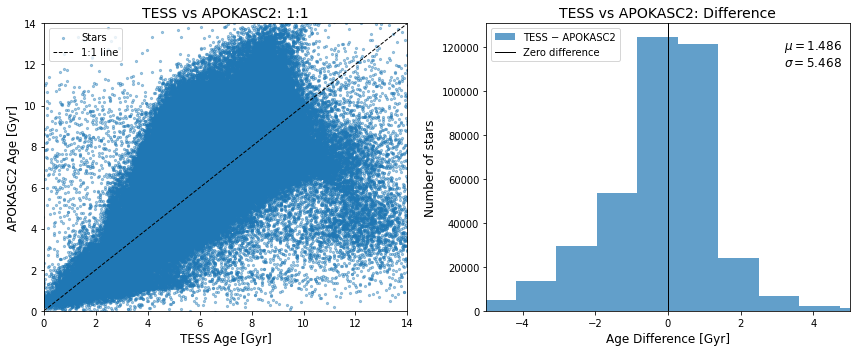

In [24]:
#1. TESS vs APOKASC2
plot_1to1_and_hist(
    filename='TESS_APOKASC2_Comparison.csv',
    age_col_1='TESS_predicted_Gyr',
    age_col_2='APOKASC2_predicted_Gyr',
    label_1='TESS',
    label_2='APOKASC2',
    title_prefix='TESS vs APOKASC2'
)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

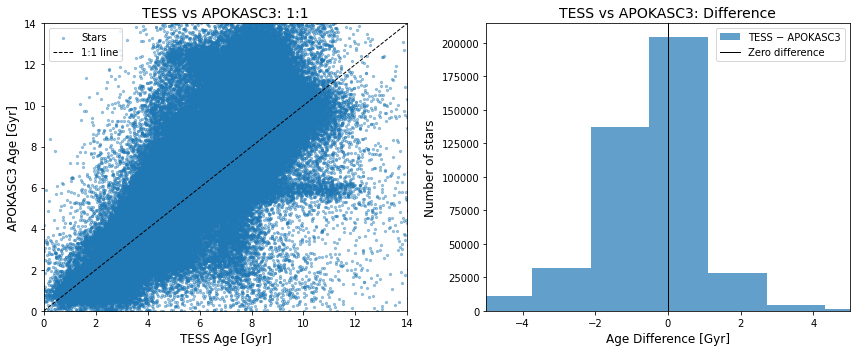

In [19]:
#2. TESS vs APOKASC3
plot_1to1_and_hist(
    filename='TESS_APOKASC3_Comparison.csv',
    age_col_1='TESS_predicted_Gyr',
    age_col_2='APOKASC3_predicted_Gyr',
    label_1='TESS',
    label_2='APOKASC3',
    title_prefix='TESS vs APOKASC3'
)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

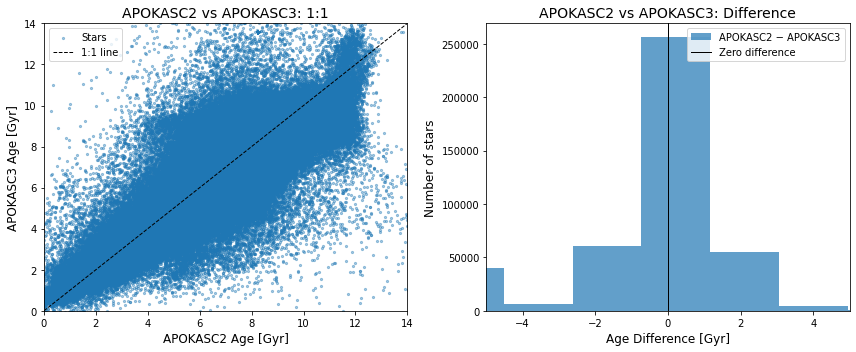

In [20]:
#3. APOKASC2 vs APOKASC3
plot_1to1_and_hist(
    filename='Task7_APOKASC2v3_predictedages_good.csv',
    age_col_1='Age_APOKASC2_Gyr',
    age_col_2='Age_APOKASC3_Gyr',
    label_1='APOKASC2',
    label_2='APOKASC3',
    title_prefix='APOKASC2 vs APOKASC3'
)

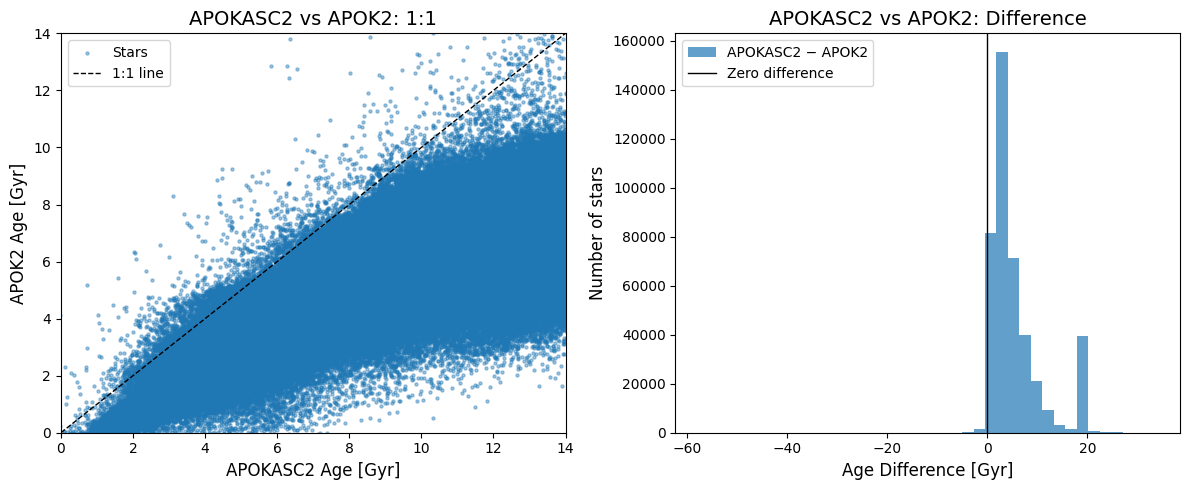

In [12]:
#4. APOKASC2 vs APOK2
plot_1to1_and_hist(
    filename='APOK2_APOKASC2_Comparison.csv',
    age_col_1='APOK2_predicted_Gyr',
    age_col_2='APOKASC2_predicted_Gyr',
    label_1='APOKASC2',
    label_2='APOK2',
    title_prefix='APOKASC2 vs APOK2'
)

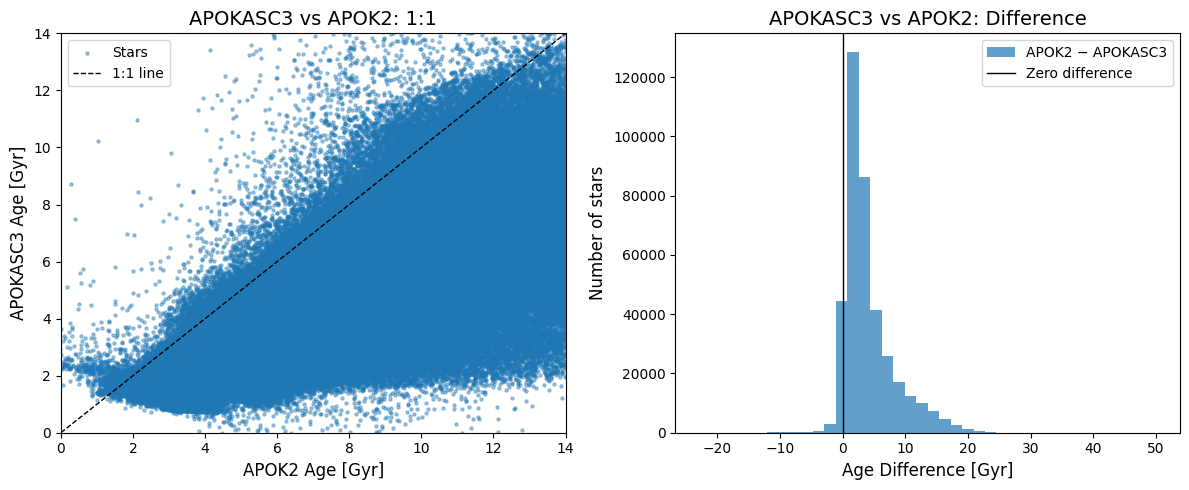

In [13]:
#5. APOKASC3 vs APOK2
plot_1to1_and_hist(
    filename='Task9_apok2_apokasc3_table.csv',
    age_col_1='apok2_predicted_age',
    age_col_2='apokasc3_predicted_age',
    label_1='APOK2',
    label_2='APOKASC3',
    title_prefix='APOKASC3 vs APOK2'
)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

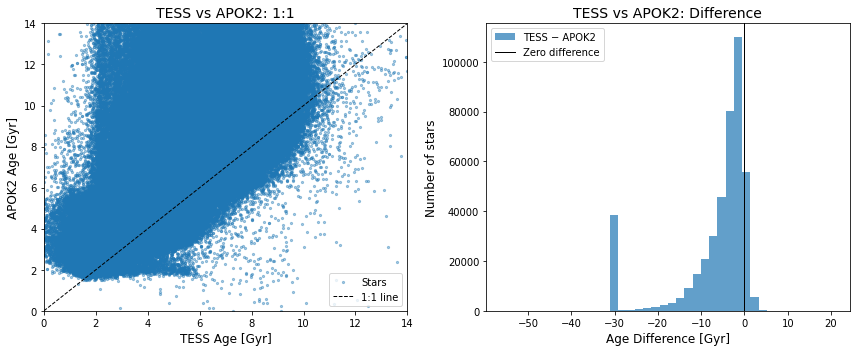

In [13]:
#6. TESS vs APOK2
plot_1to1_and_hist(
    filename='TESS_APOK2_Comparison.csv',
    age_col_1='TESS_predicted_Gyr',
    age_col_2='APOK2_predicted_Gyr',
    label_1='TESS',
    label_2='APOK2',
    title_prefix='TESS vs APOK2'
)

In [50]:
from astropy.io import fits

fname = "DR19seisages_samp_train456789_net10_method14151617_cluster1819_v2.fits"

with fits.open(fname, memmap=True) as hdul:
    cols = hdul["STARFLOW_TABLE"].columns.names
    print(len(cols))
    print(cols)

423
['sdss_id', 'sdss4_apogee_id', 'gaia_dr2_source_id', 'gaia_dr3_source_id', 'tic_v8_id', 'healpix', 'lead', 'version_id', 'catalogid', 'catalogid21', 'catalogid25', 'catalogid31', 'n_associated', 'n_neighborhood', 'sdss5_target_flags', 'sdss4_apogee_target1_flags', 'sdss4_apogee_target2_flags', 'sdss4_apogee2_target1_flags', 'sdss4_apogee2_target2_flags', 'sdss4_apogee2_target3_flags', 'sdss4_apogee_member_flags', 'sdss4_apogee_extra_target_flags', 'ra', 'dec', 'l', 'b', 'plx', 'e_plx', 'pmra', 'e_pmra', 'pmde', 'e_pmde', 'gaia_v_rad', 'gaia_e_v_rad', 'g_mag', 'bp_mag', 'rp_mag', 'j_mag', 'e_j_mag', 'h_mag', 'e_h_mag', 'k_mag', 'e_k_mag', 'ph_qual', 'bl_flg', 'cc_flg', 'w1_mag', 'e_w1_mag', 'w1_flux', 'w1_dflux', 'w1_frac', 'w2_mag', 'e_w2_mag', 'w2_flux', 'w2_dflux', 'w2_frac', 'w1uflags', 'w2uflags', 'w1aflags', 'w2aflags', 'mag4_5', 'd4_5m', 'rms_f4_5', 'sqf_4_5', 'mf4_5', 'csf', 'zgr_teff', 'zgr_e_teff', 'zgr_logg', 'zgr_e_logg', 'zgr_fe_h', 'zgr_e_fe_h', 'zgr_e', 'zgr_e_e', 'zg

In [51]:
import numpy as np
import matplotlib.pyplot as plt













findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

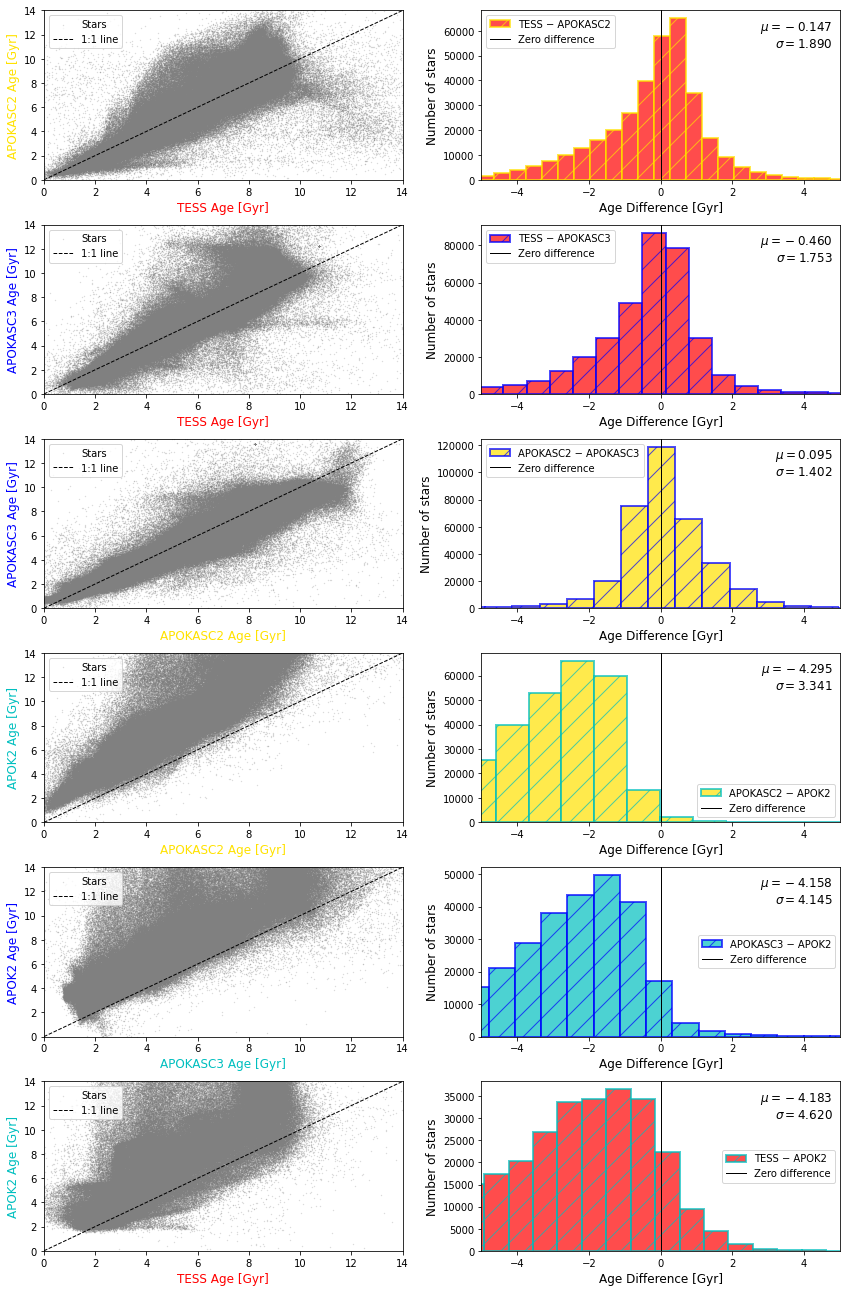

In [65]:
comparisons = [

    ('ZS_TESS_training_Age', 'ZS_AP2_training_Age',
     'TESS', 'APOKASC2', 'TESS vs APOKASC2', 'r', '#FFE200'),
    ('HK_TESS_training_Age', 'HK_AP3_training_Age',
     'TESS', 'APOKASC3', 'TESS vs APOKASC3', 'r', 'b'),
    ('RF_AP2_training_Age', 'RF_AP3_training_Age',
     'APOKASC2', 'APOKASC3', 'APOKASC2 vs APOKASC3', '#FFE200', 'b'),
    ('NM_AP2_training_Age', 'NM_AK2_training_Age',
     'APOKASC2', 'APOK2', 'APOKASC2 vs APOK2', '#FFE200', 'c'),
    ('EP_AP3_training_age','EP_AK2_Training_Age',
     'APOKASC3', 'APOK2', 'APOK2 vs APOKASC3 ', 'c', 'b'),
    ('LM_TESS_training_Age', 'LM_AK2_training_Age',
     'TESS', 'APOK2', 'TESS vs APOK2', 'r', 'c')
]

nrows = len(comparisons)
fig, axs = plt.subplots(nrows, 2, figsize=(12, 3*nrows))
fname = "DR19seisages_samp_train456789_net10_method14151617_cluster1819_v2.fits"


for i, (c1, c2, l1, l2, title, color1, color2) in enumerate(comparisons):

    with fits.open(fname, memmap=True) as hdul:
        data = hdul["STARFLOW_TABLE"].data

    agecolumn = c1
    baseage   = c2

    feh_col = "fe_h"
    c_col   = "c_h"
    n_col   = "n_h"

    good = np.where(
        np.isfinite(data[agecolumn]) & np.isfinite(data[baseage]) &
        (data[agecolumn] > 0) & (data[baseage] > 0) &

        np.isfinite(data[feh_col]) & (data[feh_col] != -9999) &
        np.isfinite(data[c_col])   & (data[c_col]   != -9999) &
        np.isfinite(data[n_col])   & (data[n_col]   != -9999)
        )

    
#    df = pd.read_csv(fname)[[c1, c2]].dropna()
    age1 = data[c1][good]
    age2 = data[c2][good]
    diff = age1 - age2  
    mu = np.mean(diff)
    sigma = np.std(diff)
#    print(color1)

    #1:1 scatter
    axs[i, 0].scatter(age1, age2, s=0.1, alpha=0.4, c='grey', label='Stars')
    axs[i, 0].plot([0, 14], [0, 14], 'k--', lw=1, label='1:1 line')
    axs[i, 0].set_xlim(0, 14)
    axs[i, 0].set_ylim(0, 14)
    axs[i, 0].set_ylabel(f'{l2} Age [Gyr]', color=color2)
    axs[i, 0].set_xlabel(f'{l1} Age [Gyr]', color=color1)
#    axs[i, 0].set_title(title)
    axs[i, 0].legend(loc='upper left')
#facecolor={color1},
    
    #histogram
    axs[i, 1].hist(diff, bins=100, alpha=0.7, linewidth=2, facecolor=color1, hatch='/', edgecolor=color2, fill=True, label=f'{l1} − {l2}')
    axs[i, 1].axvline(0, color='k', lw=1, label='Zero difference')
    axs[i, 1].set_xlim(-5, 5)
    axs[i, 1].set_ylabel('Number of stars')
    axs[i, 1].set_xlabel( 'Age Difference [Gyr]')
#    axs[i, 1].set_title(title)
    axs[i, 1].text(
        0.98, 0.95,
        rf'$\mu={mu:.3f}$' + '\n' + rf'$\sigma={sigma:.3f}$',
        transform=axs[i,1].transAxes,
        ha='right', va='top',
        fontsize=12)
    axs[i, 1].legend()

#axs[-1, 0].set_xlabel('Age [Gyr]')
#axs[-1, 1].set_xlabel('Age Difference [Gyr]')

plt.tight_layout()
plt.savefig('Figure4.png', dpi=600)
plt.show()
